# Bitcoin Portfolio Insurance — Simulated Backtest

Backtests the `drawdown_allocator` strategy against a fixed-mix benchmark using Monte Carlo simulated BTC-like returns.

**Strategy:** Bitcoin (PSP) + USDC/cash (GHP), dynamically rebalanced so the portfolio never loses more than `maxdd` from its peak.

**Scope:** Simulated data only. Real BTC data is covered in `02_real_data_backtest.ipynb`.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import erk

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

## 1. Simulate BTC-like Price Paths (GBM)

Asset prices follow a **Geometric Brownian Motion**:

$$\frac{dS_t}{S_t} = \mu \, dt + \sigma \, dW_t$$

Discretized over steps $\Delta t = 1/\text{steps\_per\_year}$, each gross return is drawn from:

$$\frac{S_{t+\Delta t}}{S_t} \sim \mathcal{N}\!\left((1+\mu)^{\Delta t},\ \sigma\sqrt{\Delta t}\right)$$

The drift uses $(1+\mu)^{\Delta t}$ rather than $1+\mu\Delta t$ to avoid compounding bias — at $\mu=0.60$ the naive form overstates annual drift by ~20%.

Price paths shape: (61, 500)  (steps x scenarios)


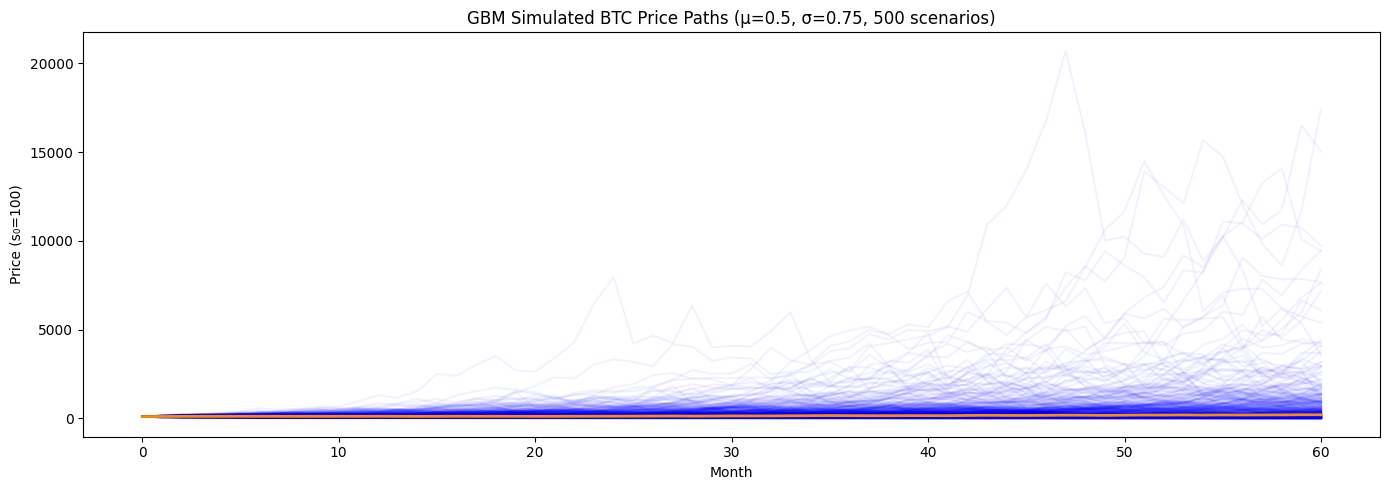

In [2]:
np.random.seed(42)

N_YEARS = 5
N_SCENARIOS = 500
STEPS_PER_YEAR = 12  # monthly steps → 60 periods
MU = 0.50
SIGMA = 0.75

btc_prices = erk.gbm(
    n_years=N_YEARS,
    n_scenarios=N_SCENARIOS,
    mu=MU,
    sigma=SIGMA,
    steps_per_year=STEPS_PER_YEAR,
    s_0=100.0,
    prices=True
)

print(f"Price paths shape: {btc_prices.shape}  (steps x scenarios)")

# Fan chart of price paths
fig, ax = plt.subplots()
btc_prices.plot(ax=ax, alpha=0.05, color='blue', legend=False)
btc_prices.median(axis=1).plot(ax=ax, color='darkorange', linewidth=2, label='Median')
ax.set_title(f'GBM Simulated BTC Price Paths (μ={MU}, σ={SIGMA}, {N_SCENARIOS} scenarios)')
ax.set_xlabel('Month')
ax.set_ylabel('Price (s₀=100)')
#ax.legend()
plt.tight_layout()

## 2. Convert Price Paths to Returns

Drop the `s_0` row, compute period-over-period returns. Safe asset (USDC) earns a flat 3% annualized rate.

In [3]:
btc_rets = btc_prices.pct_change().dropna()
btc_rets.index = range(len(btc_rets))  # integer index for bt_mix compatibility

RISKFREE_RATE = 0.03  # annualized
safe_monthly = (1 + RISKFREE_RATE) ** (1 / STEPS_PER_YEAR) - 1
usdc_rets = pd.DataFrame(
    data=safe_monthly,
    index=btc_rets.index,
    columns=btc_rets.columns
)

print(f"Return series shape: {btc_rets.shape}  (months x scenarios)")
print(f"Monthly safe rate: {safe_monthly:.4%}  ({RISKFREE_RATE:.0%} annualized)")

Return series shape: (60, 500)  (months x scenarios)
Monthly safe rate: 0.2466%  (3% annualized)


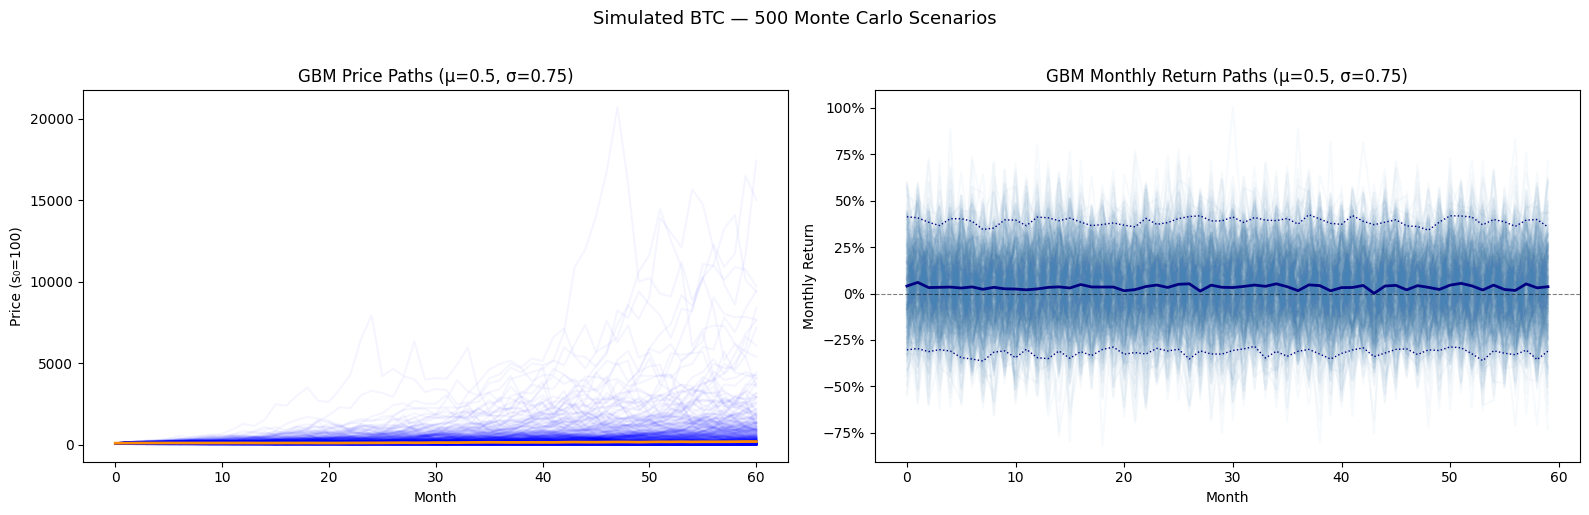

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Price paths ---
btc_prices.plot(ax=axes[0], alpha=0.04, color='blue', legend=False)
btc_prices.median(axis=1).plot(ax=axes[0], color='darkorange', linewidth=2, label='Median')
axes[0].set_title(f'GBM Price Paths (μ={MU}, σ={SIGMA})')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Price (s₀=100)')
#axes[0].legend()

# --- Return paths ---
btc_rets.plot(ax=axes[1], alpha=0.04, color='steelblue', legend=False)
btc_rets.median(axis=1).plot(ax=axes[1], color='navy', linewidth=2, label='Median')
btc_rets.quantile(0.05, axis=1).plot(ax=axes[1], color='navy', linewidth=1, linestyle=':', label='5th / 95th pct')
btc_rets.quantile(0.95, axis=1).plot(ax=axes[1], color='navy', linewidth=1, linestyle=':')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[1].set_title(f'GBM Monthly Return Paths (μ={MU}, σ={SIGMA})')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Monthly Return')
#axes[1].legend()

plt.suptitle(f'Simulated BTC — {N_SCENARIOS} Monte Carlo Scenarios', fontsize=13, y=1.02)
plt.tight_layout()

## 3. Strategy 1 — Fixed Mix Benchmark (80% BTC / 20% USDC)

In [5]:
fm_rets = erk.bt_mix(btc_rets, usdc_rets, allocator=erk.fixedmix_allocator, w1=0.80)
fm_wealth = (1 + fm_rets).cumprod()

print(f"Fixed Mix terminal wealth — median: {fm_wealth.iloc[-1].median():.2f}x  "
      f"5th pct: {fm_wealth.iloc[-1].quantile(0.05):.2f}x  "
      f"95th pct: {fm_wealth.iloc[-1].quantile(0.95):.2f}x")

Fixed Mix terminal wealth — median: 2.34x  5th pct: 0.22x  95th pct: 17.98x


## 4. CPPI Single-Scenario Walkthrough

`run_cppi` operates on a single return series and returns a detailed dict. Used here for narrative illustration only — it is not compatible with `bt_mix`'s multi-scenario allocator interface.

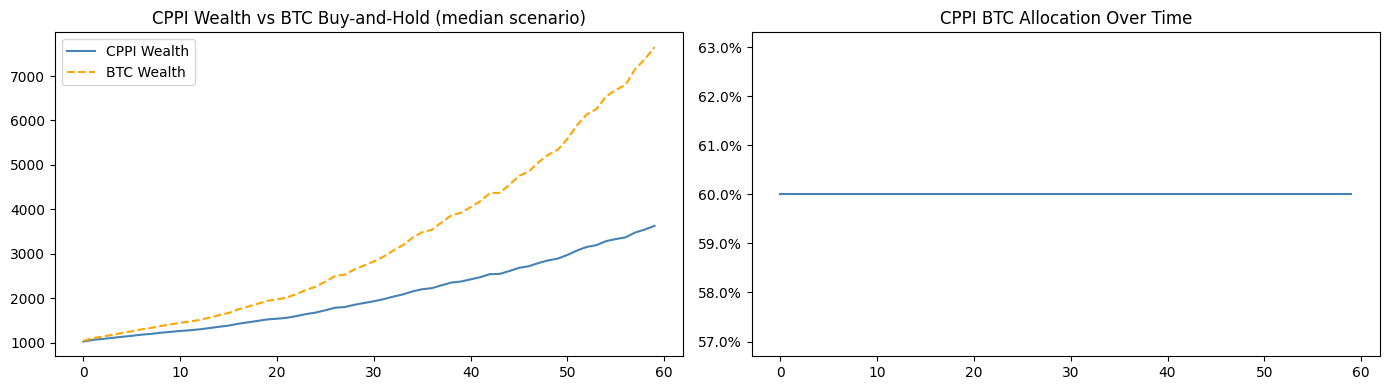

In [6]:
# Use the median scenario for the walkthrough
median_col = btc_rets.median(axis=1).rename('BTC')

cppi_result = erk.run_cppi(
    risky_r=median_col,
    safe_r=None,
    m=3,
    start=1000,
    floor=0.80,
    riskfree_rate=RISKFREE_RATE,
    drawdown=0.20
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

cppi_result['Wealth'].plot(ax=axes[0], legend=False, color='steelblue')
cppi_result['Risky Wealth'].plot(ax=axes[0], legend=False, color='orange', linestyle='--')
axes[0].set_title('CPPI Wealth vs BTC Buy-and-Hold (median scenario)')
axes[0].legend(['CPPI Wealth', 'BTC Wealth'])

cppi_result['Risky Allocation'].plot(ax=axes[1], legend=False, color='steelblue')
axes[1].set_title('CPPI BTC Allocation Over Time')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.tight_layout()

## 5. Strategy 2 — Drawdown Allocator (Core Strategy)

Runs across all 500 scenarios via `bt_mix`. Guarantees the portfolio never loses more than `maxdd=20%` from its running peak.

In [7]:
MAXDD = 0.30
M = 3

dd_rets = erk.bt_mix(
    btc_rets,
    usdc_rets,
    allocator=erk.drawdown_allocator,
    maxdd=MAXDD,
    m=M
)
dd_wealth = (1 + dd_rets).cumprod()

print(f"Drawdown Allocator terminal wealth — median: {dd_wealth.iloc[-1].median():.2f}x  "
      f"5th pct: {dd_wealth.iloc[-1].quantile(0.05):.2f}x  "
      f"95th pct: {dd_wealth.iloc[-1].quantile(0.95):.2f}x")

Drawdown Allocator terminal wealth — median: 1.18x  5th pct: 0.69x  95th pct: 5.56x


## 6. Wealth Fan Charts — Strategy Comparison

/var/folders/w5/rkx8kk090wqfvryy286gr7g40000gn/T/ipykernel_82614/1515518990.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


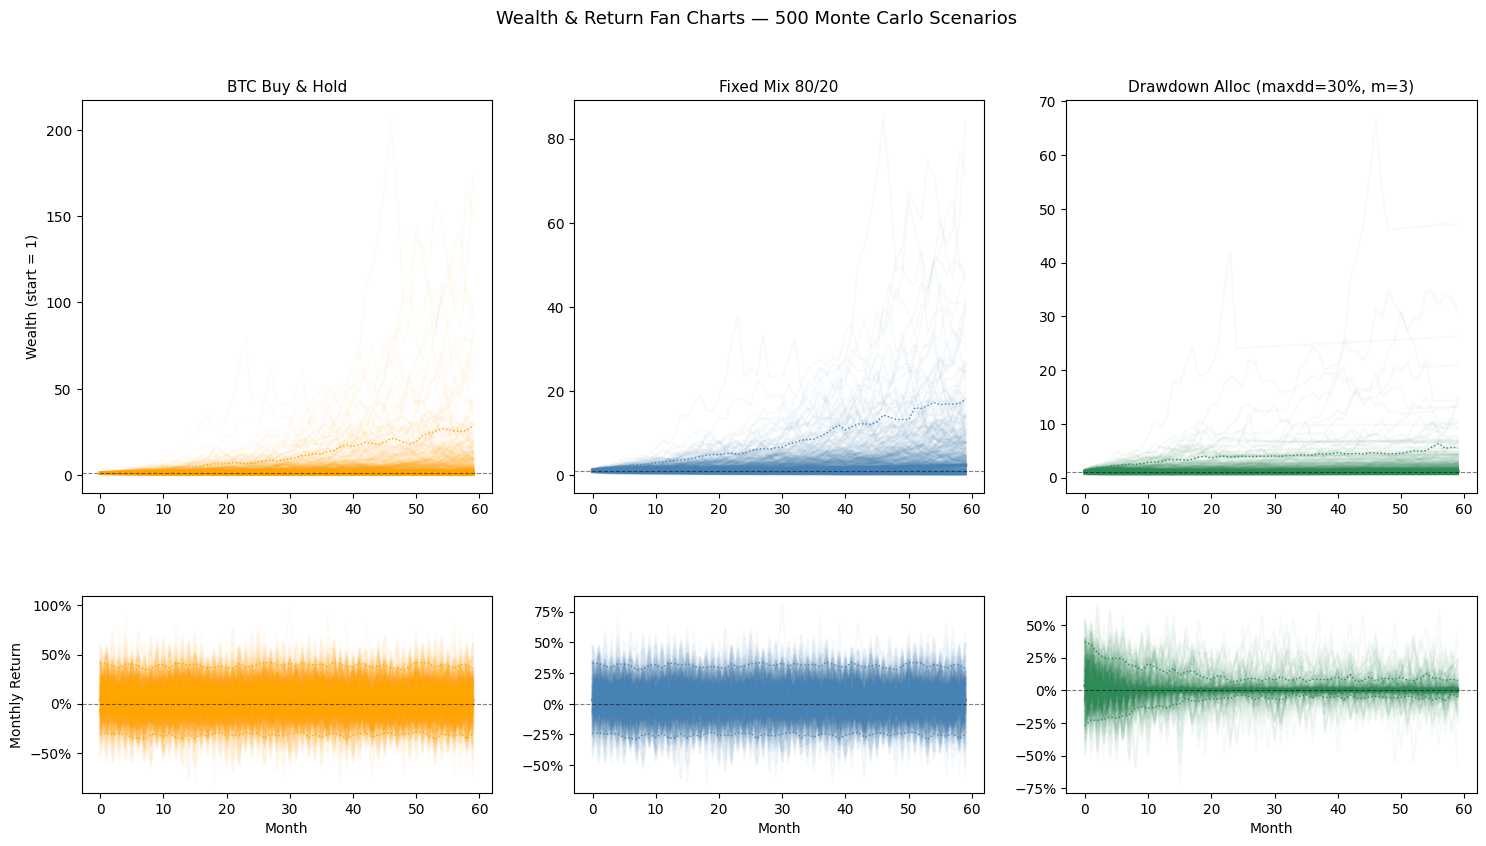

In [8]:
btc_wealth = (1 + btc_rets).cumprod()

strategies = [
    (btc_wealth, btc_rets,  'BTC Buy & Hold',                           'orange'),
    (fm_wealth,  fm_rets,   'Fixed Mix 80/20',                           'steelblue'),
    (dd_wealth,  dd_rets,   f'Drawdown Alloc (maxdd={MAXDD:.0%}, m={M})', 'seagreen'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9),
                         gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.35})

for col, (wealth, rets, title, color) in enumerate(strategies):
    w = wealth.astype(float)
    r = rets.astype(float)

    # --- top: wealth levels ---
    ax_w = axes[0, col]
    w.plot(ax=ax_w, alpha=0.04, color=color, legend=False)
    w.median(axis=1).plot(ax=ax_w, color=color, linewidth=2.5, label='Median')
    w.quantile(0.05, axis=1).plot(ax=ax_w, color=color, linewidth=1, linestyle=':', label='5th / 95th pct')
    w.quantile(0.95, axis=1).plot(ax=ax_w, color=color, linewidth=1, linestyle=':')
    ax_w.axhline(1.0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax_w.set_title(title, fontsize=11)
    ax_w.set_xlabel('')
    ax_w.set_ylabel('Wealth (start = 1)' if col == 0 else '')
#    ax_w.legend(fontsize=8)

    # --- bottom: returns ---
    ax_r = axes[1, col]
    r.plot(ax=ax_r, alpha=0.04, color=color, legend=False)
    r.median(axis=1).plot(ax=ax_r, color=color, linewidth=2, label='Median')
    r.quantile(0.05, axis=1).plot(ax=ax_r, color=color, linewidth=1, linestyle=':')
    r.quantile(0.95, axis=1).plot(ax=ax_r, color=color, linewidth=1, linestyle=':')
    ax_r.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax_r.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax_r.set_xlabel('Month')
    ax_r.set_ylabel('Monthly Return' if col == 0 else '')

plt.suptitle(f'Wealth & Return Fan Charts — {N_SCENARIOS} Monte Carlo Scenarios', fontsize=13)
plt.tight_layout()

## 7. Equity Curve — Index Performance

Median path per strategy on a single axis. Shaded bands show the 25th–75th percentile range across scenarios.

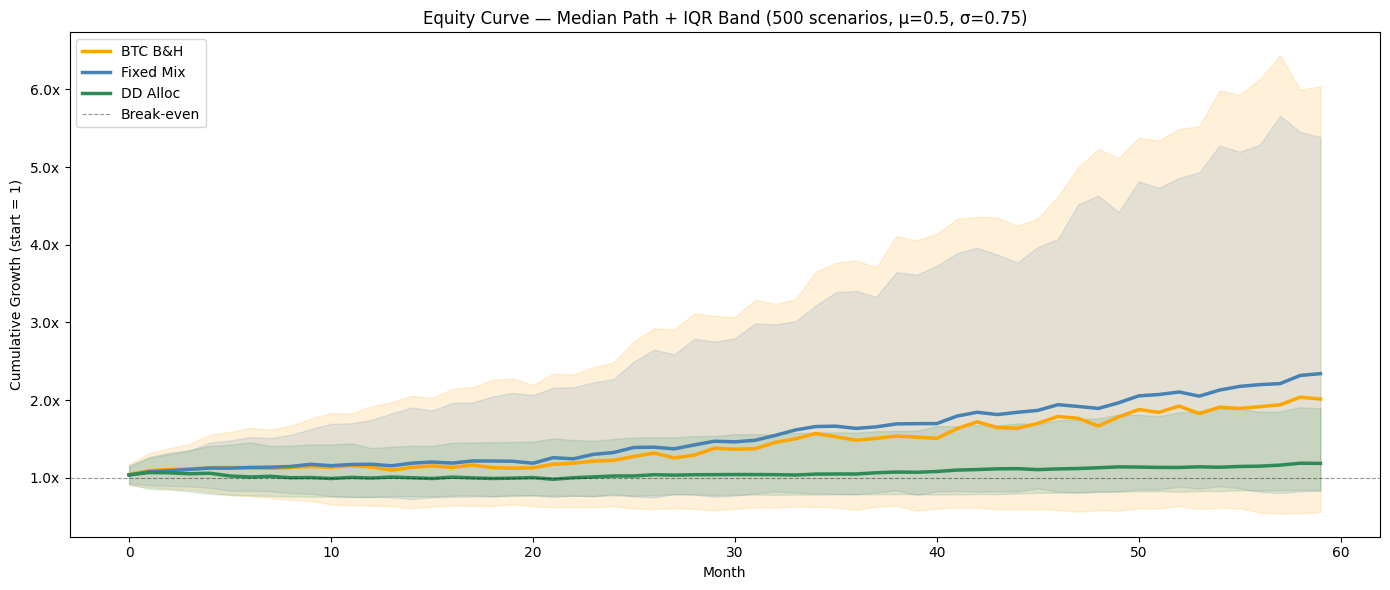

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))

palette = {
    'BTC B&H':  'orange',
    'Fixed Mix': 'steelblue',
    'DD Alloc':  'seagreen',
}

for label, wealth, color in [
    ('BTC B&H',  btc_wealth, palette['BTC B&H']),
    ('Fixed Mix', fm_wealth,  palette['Fixed Mix']),
    ('DD Alloc',  dd_wealth,  palette['DD Alloc']),
]:
    w = wealth.astype(float)
    median = w.median(axis=1)
    p25    = w.quantile(0.25, axis=1)
    p75    = w.quantile(0.75, axis=1)
    ax.plot(median.index, median.values, color=color, linewidth=2.5, label=label)
    ax.fill_between(median.index, p25.values, p75.values, color=color, alpha=0.15)

ax.axhline(1.0, color='black', linewidth=0.8, linestyle='--', alpha=0.4, label='Break-even')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.1f}x'))
ax.set_xlabel('Month')
ax.set_ylabel('Cumulative Growth (start = 1)')
ax.set_title(f'Equity Curve — Median Path + IQR Band ({N_SCENARIOS} scenarios, μ={MU}, σ={SIGMA})')
ax.legend()
plt.tight_layout()

## 8. Drawdown Distribution Comparison

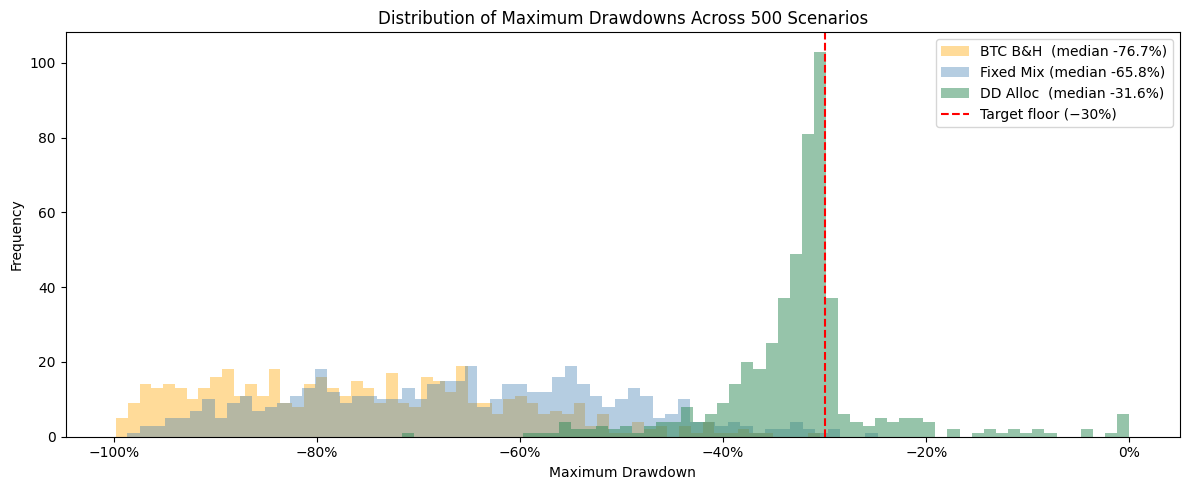

In [10]:
def max_drawdown_per_scenario(wealth_df):
    """Returns a Series of worst drawdown per scenario."""
    peaks = wealth_df.cummax()
    dds = (wealth_df - peaks) / peaks
    return dds.min()

btc_mdd = max_drawdown_per_scenario(btc_wealth)
fm_mdd  = max_drawdown_per_scenario(fm_wealth)
dd_mdd  = max_drawdown_per_scenario(dd_wealth)

fig, ax = plt.subplots(figsize=(12, 5))
btc_mdd.plot.hist(ax=ax, bins=60, alpha=0.4, color='orange',    label=f'BTC B&H  (median {btc_mdd.median():.1%})')
fm_mdd.plot.hist( ax=ax, bins=60, alpha=0.4, color='steelblue', label=f'Fixed Mix (median {fm_mdd.median():.1%})')
dd_mdd.plot.hist( ax=ax, bins=60, alpha=0.5, color='seagreen',  label=f'DD Alloc  (median {dd_mdd.median():.1%})')
ax.axvline(-MAXDD, color='red', linestyle='--', linewidth=1.5, label=f'Target floor (−{MAXDD:.0%})')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Distribution of Maximum Drawdowns Across 500 Scenarios')
ax.set_xlabel('Maximum Drawdown')
ax.legend()
plt.tight_layout()

## 9. Summary Statistics

Computed on the **median scenario** for each strategy.

> **Note:** `summary_stats` hardcodes `periods_per_year=12`. Only valid for monthly steps (`STEPS_PER_YEAR=12`).

In [11]:
stats_df = pd.DataFrame({
    'BTC B&H':    btc_rets.median(axis=1),
    'Fixed Mix':  fm_rets.median(axis=1),
    'DD Alloc':   dd_rets.median(axis=1),
})

erk.summary_stats(stats_df, riskfree_rate=RISKFREE_RATE).T

,BTC B&H,Fixed Mix,DD Alloc
Annualized Return,0.502295,0.394553,0.045011
Annualized Vol,0.041257,0.033006,0.020915
Skewness,-0.299104,-0.299104,5.025861
Kurtosis,2.869144,2.869144,26.771538
Cornish-Fisher VaR (5%),-0.014124,-0.011792,-0.008111
Historic CVaR (5%),-0.009925,-0.008433,-0.002466
Sharpe Ratio,11.146546,10.753711,0.698507
Max Drawdown,0.000000,0.000000,0.000000


## 10. Stress Test — Vary `maxdd` and Multiplier `m`

15 parameter combinations (5 maxdd × 3 m values). Reports mean terminal wealth and mean max drawdown across all scenarios.

In [12]:
maxdd_values = [0.10, 0.15, 0.20, 0.25, 0.30]
m_values     = [2, 3, 5]

rows = []
for maxdd in maxdd_values:
    for m in m_values:
        rets   = erk.bt_mix(btc_rets, usdc_rets, allocator=erk.drawdown_allocator, maxdd=maxdd, m=m)
        wealth = (1 + rets).cumprod()
        rows.append({
            'maxdd': f'{maxdd:.0%}',
            'm': m,
            'Mean Terminal Wealth': wealth.iloc[-1].mean(),
            'Median Terminal Wealth': wealth.iloc[-1].median(),
            'Avg Max Drawdown': max_drawdown_per_scenario(wealth).mean(),
            '% Breaching Floor': (max_drawdown_per_scenario(wealth) < -maxdd).mean(),
        })

stress = pd.DataFrame(rows).set_index(['maxdd', 'm'])
stress['Avg Max Drawdown']    = stress['Avg Max Drawdown'].map('{:.1%}'.format)
stress['% Breaching Floor']   = stress['% Breaching Floor'].map('{:.1%}'.format)
stress['Mean Terminal Wealth']   = stress['Mean Terminal Wealth'].map('{:.2f}x'.format)
stress['Median Terminal Wealth'] = stress['Median Terminal Wealth'].map('{:.2f}x'.format)

print(f"Stress test: {len(stress)} parameter combinations")
stress

Stress test: 15 parameter combinations


Mean Terminal Wealth Median Terminal Wealth Avg Max Drawdown  \
maxdd m                                                                
10%   2                1.43x                  1.34x            -9.5%   
      3                1.44x                  1.28x           -11.6%   
      5                1.41x                  1.22x           -15.0%   
15%   2                1.56x                  1.37x           -14.4%   
      3                1.56x                  1.28x           -17.0%   
      5                1.52x                  1.18x           -21.0%   
20%   2                1.70x                  1.40x           -19.3%   
      3                1.68x                  1.25x           -22.3%   
      5                1.65x                  1.15x           -26.7%   
25%   2                1.86x                  1.40x           -24.2%   
      3                1.83x                  1.21x           -27.4%   
      5                1.79x                  1.12x           -31.4%   
30%   2                2.06x                  1.38x           -29.0%   
      3                2.03x                  1.18x           -32.5%   
      5                1.93x                  1.09x           -36.0%   

        % Breaching Floor  
maxdd m                    
10%   2             24.8%  
      3             81.0%  
      5             93.0%  
15%   2             26.8%  
      3             80.0%  
      5             88.8%  
20%   2             27.0%  
      3             79.4%  
      5             86.0%  
25%   2             27.4%  
      3             78.8%  
      5             88.8%  
30%   2             27.8%  
      3             78.6%  
      5             90.2%